In [2]:
import pandas as pd

ratings = pd.read_csv('movie_ratings.csv')
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [3]:
movie = pd.read_csv('movie_info.csv')
movie

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [4]:
ratings.describe()
# 各列の平均や標準偏差などを指示できる
# ratingという列にはそれぞれの映画に対する評価点数の情報がある

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


meanは平均なので、映画の評価点数の平均は3.5点程度であることが分かる

以下のプログラムで、映画の評価点数を棒グラフで可視化する

<Axes: >

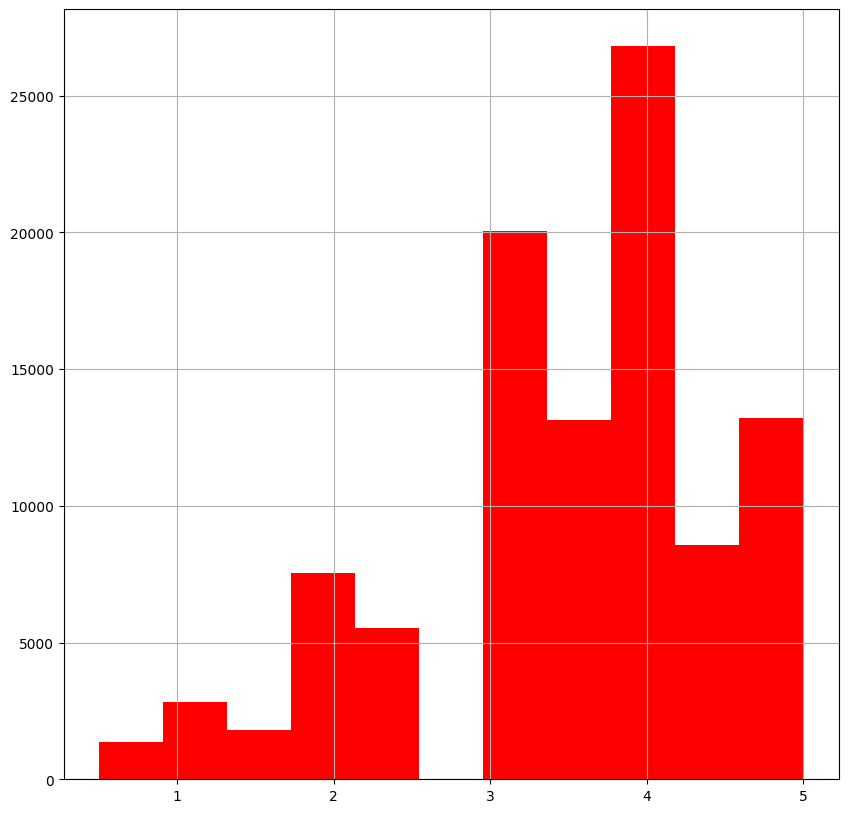

In [5]:
ratings['rating'].hist(bins=11, figsize=(10,10), color = 'red')

3点未満の人気のない映画は、全体で見た本数も少ないので、今回のレコメンド対象から外しても問題なさそう

<Axes: >

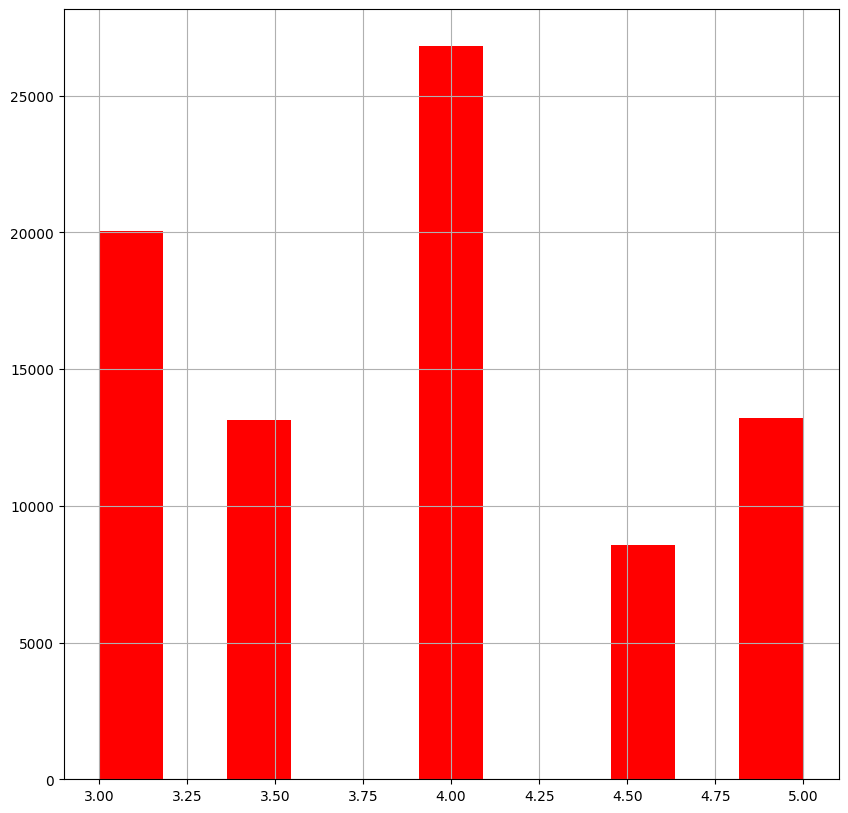

In [6]:
ratings = ratings[ratings.rating >= 3]
ratings['rating'].hist(bins=11, figsize=(10,10), color = 'red')

映画に関する要約情報とレーティング情報の2つのデータセットを結合する

In [7]:
mergeddf = ratings.merge(movie, on = 'movieId')
mergeddf

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
81758,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller
81759,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller
81760,610,168250,5.0,1494273047,Get Out (2017),Horror
81761,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi


In [9]:
# 協調フィルタリングに必要な列のみ抽出(ユーザID、映画タイトル、評価点数)
mergeddf = mergeddf[['userId','title','rating']]
mergeddf

,userId,title,rating
0,1,Toy Story (1995),4.0
1,1,Grumpier Old Men (1995),4.0
2,1,Heat (1995),4.0
3,1,Seven (a.k.a. Se7en) (1995),5.0
4,1,"Usual Suspects, The (1995)",5.0
...,...,...,...
81758,610,Split (2017),4.0
81759,610,John Wick: Chapter Two (2017),5.0
81760,610,Get Out (2017),5.0
81761,610,Logan (2017),5.0


In [10]:
# 同じユーザが同じ映画に二回以上評価している場合を考慮して、重複行を削除する
mergeddf = mergeddf.drop_duplicates(['userId','title'])
mergeddf

,userId,title,rating
0,1,Toy Story (1995),4.0
1,1,Grumpier Old Men (1995),4.0
2,1,Heat (1995),4.0
3,1,Seven (a.k.a. Se7en) (1995),5.0
4,1,"Usual Suspects, The (1995)",5.0
...,...,...,...
81758,610,Split (2017),4.0
81759,610,John Wick: Chapter Two (2017),5.0
81760,610,Get Out (2017),5.0
81761,610,Logan (2017),5.0


ピボットテーブルの作成

In [11]:
# 行を映画タイトル、列をユーザIDとしたテーブル
movie_pivot = mergeddf.pivot(index = 'title',columns='userId',values='rating').fillna(0)
movie_pivot

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Salem's Lot (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[REC]³ 3 Génesis (2012),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
anohana: The Flower We Saw That Day - The Movie (2013),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
eXistenZ (1999),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,4.5,0.0,0.0


K近傍法の実行

In [12]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=9,algorithm= 'brute', metric='cosine')
movie_pivot_sparse = csr_matrix(movie_pivot.values)
model = knn.fit(movie_pivot_sparse)

In [15]:
Movie = 'Iron Man (2008)'

distance, indice = model.kneighbors(movie_pivot.iloc[movie_pivot.index==Movie].values.reshape(1,-1),n_neighbors=11)
for i in range(0, len(distance.flatten())):
  if i == 0:
    print('Recommendations if you like the movie {0}:\n'.format(movie_pivot[movie_pivot.index==Movie].index[0]))
  else:
    print('{0}: {1} with distance {2}'.format(i,movie_pivot.index[indice.flatten()[i]],distance.flatten()[i]))

Recommendations if you like the movie Iron Man (2008):

1: Dark Knight, The (2008) with distance 0.3535593545146176
2: WALL·E (2008) with distance 0.3610591276390127
3: Avengers, The (2012) with distance 0.3649033681548768
4: Iron Man 2 (2010) with distance 0.36759723492909513
5: Avatar (2009) with distance 0.41101652935211297
6: Up (2009) with distance 0.417333104936607
7: Batman Begins (2005) with distance 0.4248561040495944
8: Guardians of the Galaxy (2014) with distance 0.4258684717651423
9: Star Trek (2009) with distance 0.42760585824904684
10: Watchmen (2009) with distance 0.4396196773592028
